# Category: Food, Water & Amenities 
We will conduct our exploratory data analysis for this category using selected variables. Then we will create a scoring system using PCA. Finally, we will validate our results using real migration data.

# Setup

In [1]:
import os
import sys
import math
import json
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("food_water_and_amenities.csv")

In [3]:
df

,FIPS,State,County,broadband access raw value2021,broadband access raw value2022,broadband access raw value2023,broadband access raw value2024,broadband access raw value2025,drinking water violations raw value2013,drinking water violations raw value2014,...,RECFACPTH20,PCT_LACCESS_POP10,PCT_LACCESS_POP15,PCT_LACCESS_POP19,FOODHUB12,FOODHUB16,FOODHUB18,FOODHUB23,Longitude,Latitude
0,0,USA,USA,0.826665,0.852466,0.870007,0.883467,0.897119,0.052527,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1000,NaN,NaN,0.763991,0.799154,0.820457,0.837864,0.856199,0.012790,0.026992,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1001,AL,Autauga,0.805674,0.827079,0.854639,0.890667,0.908804,0.000000,0.000000,...,0.160299,33.769657,32.062255,33.906700,0.0,0.0,NaN,0.0,-86.642900,32.535142
3,1003,AL,Baldwin,0.818164,0.850691,0.878564,0.889209,0.897509,0.078552,0.042154,...,0.095950,19.318473,16.767489,25.122238,0.0,0.0,NaN,0.0,-87.722745,30.727825
4,1005,AL,Barbour,0.605243,0.646321,0.646127,0.682232,0.723018,0.077501,0.317124,...,-9999.000000,20.840972,22.105560,20.520679,0.0,0.0,NaN,0.0,-85.391068,31.870090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3291,72145,PR,Vega Baja,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-66.397313,18.428731
3292,72147,PR,Vieques,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-65.439233,18.122444
3293,72149,PR,Villalba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-66.471754,18.128246
3294,72151,PR,Yabucoa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-65.896220,18.070186



## Initial profiling


We have the following variables according to years.

| Variable                            | Explanation                                                                              |
| ----------------------------------- | ---------------------------------------------------------------------------------------- |
| food environment index raw value    | Index of factors that contribute to a healthy food environment, from 0 worst to 10 best. |
| broadband access raw value          | Percentage of households with a broadband internet connection.                           |
| drinking water violations raw value | Indicator of the presence of health-related drinking water violations. 0 = No, 1 = Yes.  |
| food insecurity raw value           | Percentage of the population that lacks adequate access to food.                         |
| FOODHUB                             | Number of food hubs.                                                                     |
| PCT_LACCESS_POP                     | Percentage of the population with low access to a store.                                 |
| RECFACPTH                           | Number of recreation and fitness facilities per 1,000 people.                            |


In [4]:
print('Rows:', len(df), 'Columns:', df.shape[1])
display(df.drop(columns=['FIPS','State','County','Longitude','Latitude']).describe(include='all').T)

Rows: 3296 Columns: 61


,count,mean,std,min,25%,50%,75%,max
broadband access raw value2021,3193.0,0.755071,0.088286,0.347686,0.706148,0.765561,0.815452,0.960285
broadband access raw value2022,3193.0,0.786431,0.082306,0.333333,0.742049,0.797647,0.842381,0.970588
broadband access raw value2023,3193.0,0.806363,0.078690,0.370370,0.765630,0.817930,0.860638,0.975904
broadband access raw value2024,3194.0,0.825311,0.072058,0.359694,0.788107,0.835667,0.875082,1.000000
broadband access raw value2025,3195.0,0.844288,0.065583,0.481383,0.811180,0.853604,0.889590,1.000000
drinking water violations raw value2013,3133.0,0.095670,0.199659,0.000000,0.000000,0.002487,0.081248,1.000000
drinking water violations raw value2014,3133.0,0.091706,0.167213,0.000000,0.000000,0.012906,0.103259,1.000000
drinking water violations raw value2015,3131.0,0.091504,0.169640,0.000000,0.000000,0.010683,0.099711,1.000000
drinking water violations raw value2016,3130.0,0.519564,0.496747,0.000000,0.000000,1.000000,1.000000,1.000000
drinking water violations raw value2017,3125.0,0.519115,0.496760,0.000000,0.000000,1.000000,1.000000,1.000000


## Missingness analysis


Observe that the standard deviation for some data is very high. That is because, in that source, missing data was replaced with very high negative numbers like -8888 and -9999. First, we will replace all such values with NaN and then conduct our missingness analysis.

In [5]:
df = df.replace([-8888, -9999], np.nan)

In [6]:
import missingno as msno

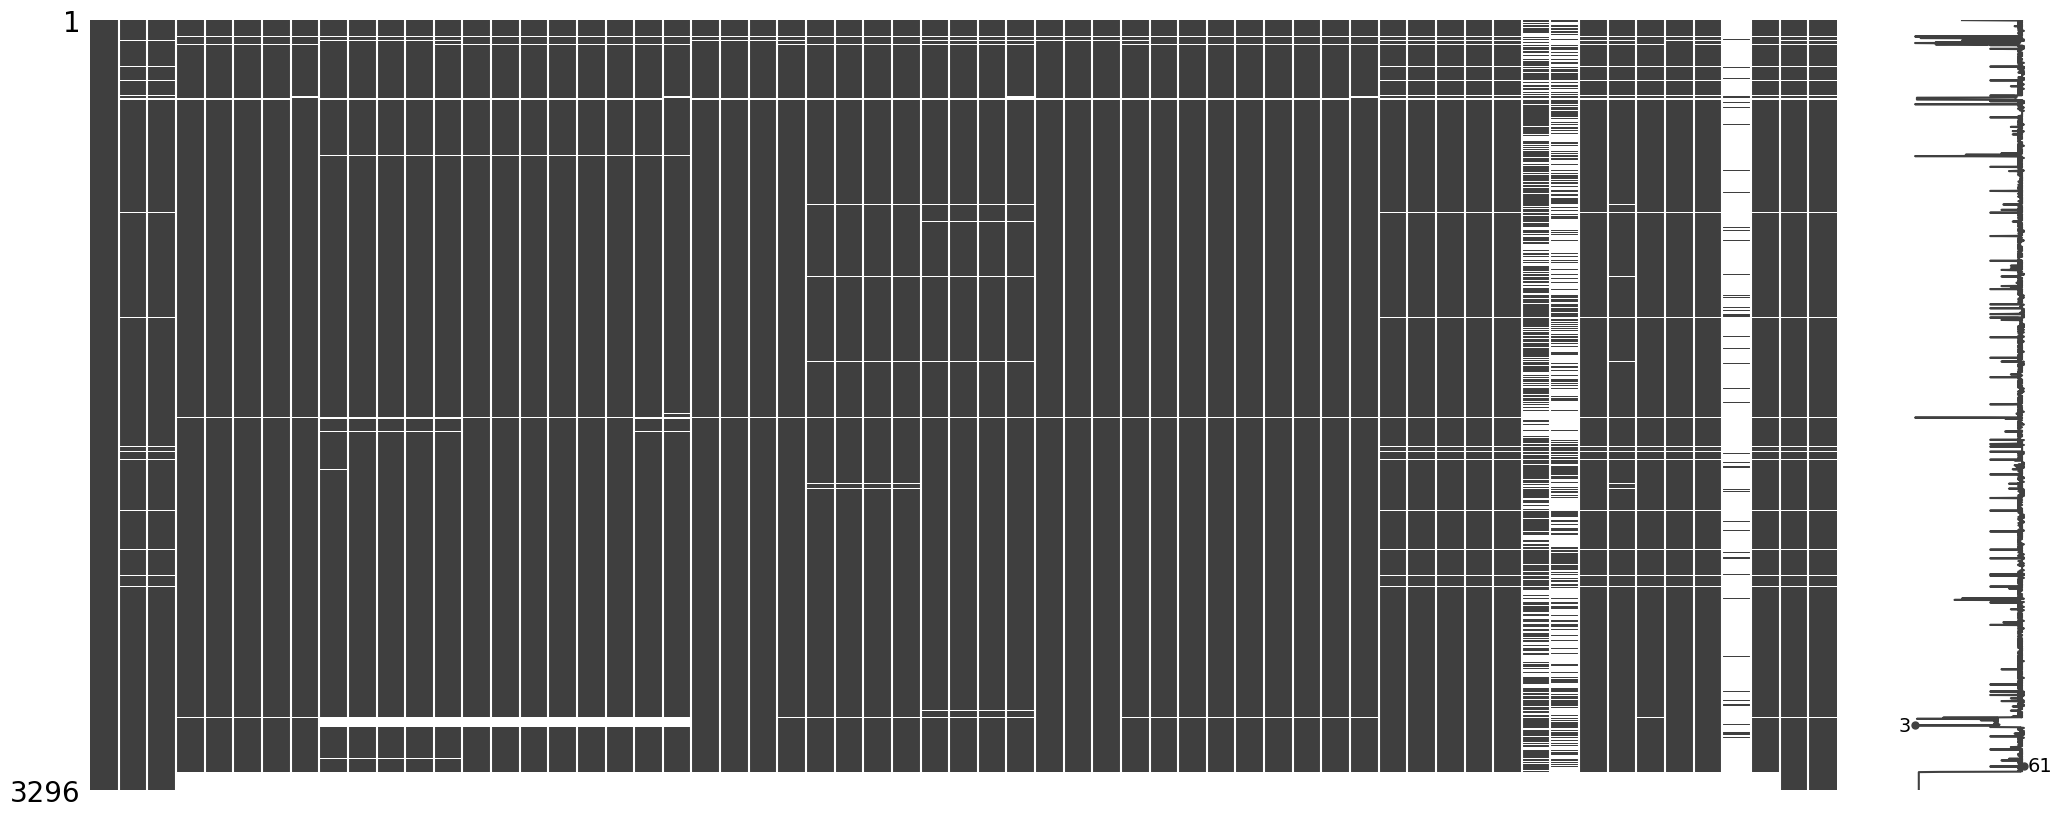

In [7]:
msno.matrix(df)
plt.show()

We notice that some rows have a lot of missing data. 

In [8]:
missing_fraction = df.isna().mean(axis=1)

rows_missing_data = df[missing_fraction > 0.90]

print('Total number of counties missing more than 90% of data is '+ str(len(rows_missing_data)))
display(rows_missing_data[['FIPS', 'State', 'County']])

Total number of counties missing more than 90% of data is 96


,FIPS,State,County
70,2010,AK,Aleutian Islands
76,2063,NaN,NaN
77,2066,NaN,NaN
98,2231,AK,Skagway-Yakutat-Angoon
332,9110,NaN,NaN
...,...,...,...
3291,72145,PR,Vega Baja
3292,72147,PR,Vieques
3293,72149,PR,Villalba
3294,72151,PR,Yabucoa


We note the lack of data for Puerto Rico.

In [9]:
missing_fraction_cols = df.isna().mean(axis=0)

worst_col = missing_fraction_cols.idxmax()

print("Column with most missing data:", worst_col)
print("Missing percent:", missing_fraction_cols[worst_col] * 100)
print("Missing count:", df[worst_col].isna().sum())

Column with most missing data: FOODHUB18
Missing percent: 94.53883495145631
Missing count: 3116


So, we want to drop the FoodHub18 variable and work with the counties with enough data:

In [10]:
df_new = df[missing_fraction <= 0.90].drop(columns=['FOODHUB18'])

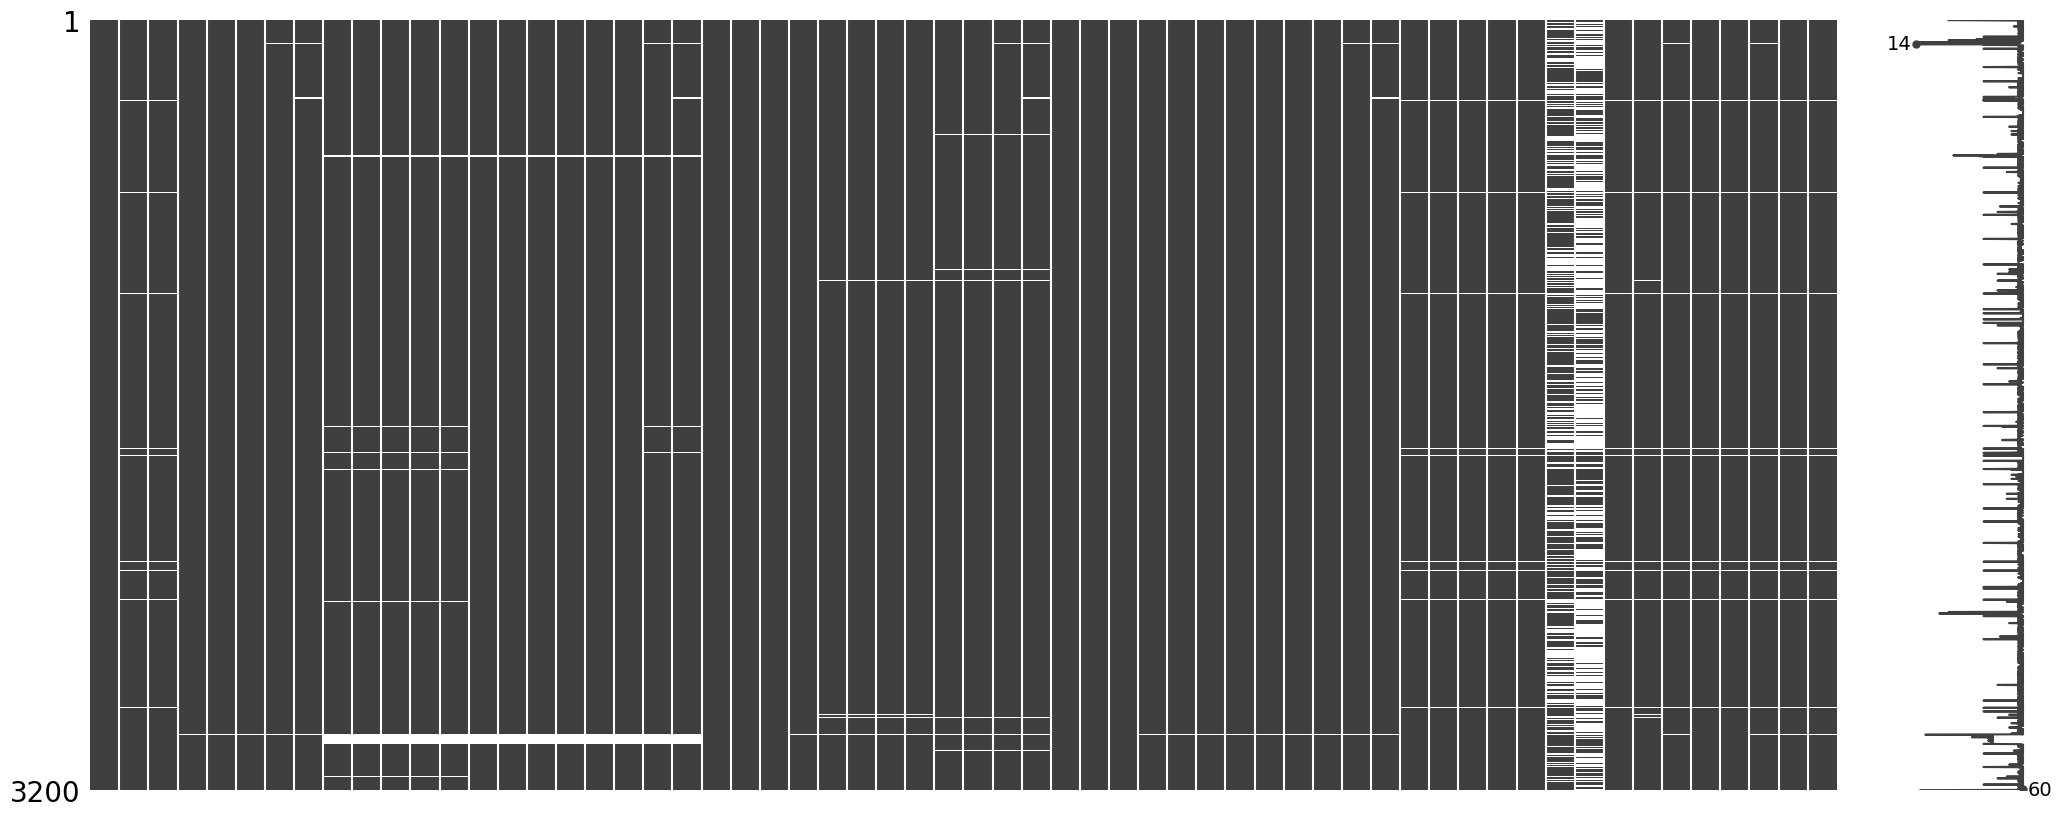

In [11]:
msno.matrix(df_new)
plt.show()

## Ranges and Impossible values


Now, let's carefully check the ranges and possible outliers for our variables.

In [12]:
food_cols = [
    "food environment index raw value2014",
    "food environment index raw value2015",
    "food environment index raw value2016",
    "food environment index raw value2017",
    "food environment index raw value2018",
    "food environment index raw value2019",
    "food environment index raw value2020",
    "food environment index raw value2021",
    "food environment index raw value2022",
    "food environment index raw value2023",
    "food environment index raw value2024",
    "food environment index raw value2025"
]

bad_food = df_new[
    (df_new[food_cols].lt(0).any(axis=1)) |
    (df_new[food_cols].gt(10).any(axis=1))
]

print("Number of impossible Food Environment Index values:", len(bad_food))

if len(bad_food) == 0:
    print("No impossible values found.")
else:
    display(bad_food[["FIPS", "State", "County"] + food_cols])

Number of impossible Food Environment Index values: 0
No impossible values found.


In [13]:
broadband_cols = [
    "broadband access raw value2021",
    "broadband access raw value2022",
    "broadband access raw value2023",
    "broadband access raw value2024",
    "broadband access raw value2025"
]

bad_bb = df_new[
    (df_new[broadband_cols].lt(0).any(axis=1)) |
    (df_new[broadband_cols].gt(1).any(axis=1))
]

print("Number of impossible Broadband Access values:", len(bad_bb))

if len(bad_bb) == 0:
    print("No impossible values found.")
else:
    display(bad_bb[["FIPS", "State", "County"] + broadband_cols])

Number of impossible Broadband Access values: 0
No impossible values found.


In [14]:
drinking_water_cols = [
    "drinking water violations raw value2013",
    "drinking water violations raw value2014",
    "drinking water violations raw value2015",
    "drinking water violations raw value2016",
    "drinking water violations raw value2017",
    "drinking water violations raw value2018",
    "drinking water violations raw value2019",
    "drinking water violations raw value2020",
    "drinking water violations raw value2021",
    "drinking water violations raw value2022",
    "drinking water violations raw value2023",
    "drinking water violations raw value2024",
    "drinking water violations raw value2025"
]

bad_water = df_new[
    (df_new[drinking_water_cols].lt(0).any(axis=1)) |
    (df_new[drinking_water_cols].gt(1).any(axis=1))
]

print("Number of impossible Drinking Water Violations values:", len(bad_water))

if len(bad_water) == 0:
    print("No impossible values found.")
else:
    display(bad_water[["FIPS", "State", "County"] +drinking_water_cols])

Number of impossible Drinking Water Violations values: 0
No impossible values found.


In [15]:
food_insecurity_cols = [
    "food insecurity raw value2014",
    "food insecurity raw value2015",
    "food insecurity raw value2016",
    "food insecurity raw value2017",
    "food insecurity raw value2018",
    "food insecurity raw value2019",
    "food insecurity raw value2020",
    "food insecurity raw value2021",
    "food insecurity raw value2022",
    "food insecurity raw value2023",
    "food insecurity raw value2024",
    "food insecurity raw value2025"
]
bad_insec = df_new[
    (df_new[food_insecurity_cols].lt(0).any(axis=1)) |
    (df_new[food_insecurity_cols].gt(1).any(axis=1))
]

print("Number of impossible Food Insecurity values:", len(bad_insec))

if len(bad_insec) == 0:
    print("No impossible values found.")
else:
    display(bad_insec[["FIPS", "State", "County"] + food_insecurity_cols])

Number of impossible Food Insecurity values: 0
No impossible values found.


In [16]:
foodhub_cols = [
    "FOODHUB12",
    "FOODHUB16",
    "FOODHUB23"
]

bad_hub = df_new[
    (df_new[foodhub_cols].lt(0).any(axis=1)) |
    (df_new[foodhub_cols].gt(10).any(axis=1))
]

print("Number of impossible Number of Food Hubs values:", len(bad_hub))

if len(bad_hub) == 0:
    print("No impossible values found.")
else:
    display(bad_hub[["FIPS", "State", "County"] + foodhub_cols])

Number of impossible Number of Food Hubs values: 0
No impossible values found.


In [17]:
low_access_pop_cols = [
    "PCT_LACCESS_POP10",
    "PCT_LACCESS_POP15",
    "PCT_LACCESS_POP19"
]

bad_acess = df_new[
    (df_new[low_access_pop_cols].lt(0).any(axis=1)) |
    (df_new[low_access_pop_cols].gt(101).any(axis=1))
]

print("Number of impossible Percentage of Low Access to Store values:", len(bad_acess))

if len(bad_acess) == 0:
    print("No impossible values found.")
else:
    display(bad_acess[["FIPS", "State", "County"] + low_access_pop_cols])

Number of impossible Percentage of Low Access to Store values: 0
No impossible values found.


In [18]:
recfacpth_cols = [
    "RECFACPTH07",
    "RECFACPTH09",
    "RECFACPTH11",
    "RECFACPTH12",
    "RECFACPTH14",
    "RECFACPTH16",
    "RECFACPTH20"
]

bad_rec = df_new[
    (df_new[recfacpth_cols].lt(0).any(axis=1)) |
    (df_new[recfacpth_cols].gt(5).any(axis=1))
]

print("Number of impossible Recreation and Fitness Facilities values:", len(bad_rec))

if len(bad_rec) == 0:
    print("No impossible values found.")
else:
    display(bad_rec[["FIPS", "State", "County"] + recfacpth_cols])

Number of impossible Recreation and Fitness Facilities values: 0
No impossible values found.


## Duplicates

In [19]:
dup_rows = df_new.duplicated(keep = False)
print('Duplicate rows:', dup_rows.sum())

Duplicate rows: 0


## Profiling After Cleanup

In [20]:
display(df_new[food_cols].describe().T)
display(df_new[broadband_cols].describe().T)
display(df_new[drinking_water_cols].describe().T)
display(df_new[food_insecurity_cols].describe().T)
display(df_new[foodhub_cols].describe().T)
display(df_new[low_access_pop_cols].describe().T)
display(df_new[recfacpth_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
food environment index raw value2014,3191.0,7.374698,1.244315,0.0,6.778079,7.577588,8.209416,10.0
food environment index raw value2015,3191.0,7.074867,1.252714,0.0,6.500000,7.300000,7.900000,10.0
food environment index raw value2016,3191.0,6.962144,1.231576,0.0,6.400000,7.200000,7.800000,10.0
food environment index raw value2017,3185.0,7.031177,1.252712,0.0,6.400000,7.300000,7.900000,10.0
food environment index raw value2018,3174.0,7.407940,1.188788,0.0,6.900000,7.600000,8.200000,10.0
food environment index raw value2019,3174.0,7.465217,1.168334,0.0,6.900000,7.700000,8.200000,10.0
food environment index raw value2020,3174.0,7.450788,1.148132,0.0,6.900000,7.600000,8.200000,10.0
food environment index raw value2021,3174.0,7.445463,1.152863,0.0,6.900000,7.600000,8.200000,10.0
food environment index raw value2022,3160.0,7.446297,1.148829,0.0,6.800000,7.600000,8.200000,10.0
food environment index raw value2023,3160.0,7.425095,1.150006,0.0,6.800000,7.600000,8.200000,10.0


,count,mean,std,min,25%,50%,75%,max
broadband access raw value2021,3193.0,0.755071,0.088286,0.347686,0.706148,0.765561,0.815452,0.960285
broadband access raw value2022,3193.0,0.786431,0.082306,0.333333,0.742049,0.797647,0.842381,0.970588
broadband access raw value2023,3193.0,0.806363,0.078690,0.370370,0.765630,0.817930,0.860638,0.975904
broadband access raw value2024,3192.0,0.825306,0.072066,0.359694,0.788131,0.835667,0.875027,1.000000
broadband access raw value2025,3184.0,0.844082,0.065573,0.481383,0.810874,0.853407,0.889179,1.000000


,count,mean,std,min,25%,50%,75%,max
drinking water violations raw value2013,3133.0,0.095670,0.199659,0.0,0.0,0.002487,0.081248,1.0
drinking water violations raw value2014,3133.0,0.091706,0.167213,0.0,0.0,0.012906,0.103259,1.0
drinking water violations raw value2015,3131.0,0.091504,0.169640,0.0,0.0,0.010683,0.099711,1.0
drinking water violations raw value2016,3130.0,0.519564,0.496747,0.0,0.0,1.000000,1.000000,1.0
drinking water violations raw value2017,3125.0,0.519115,0.496760,0.0,0.0,1.000000,1.000000,1.0
drinking water violations raw value2018,3148.0,0.432445,0.492373,0.0,0.0,0.000000,1.000000,1.0
drinking water violations raw value2019,3148.0,0.386844,0.483996,0.0,0.0,0.000000,1.000000,1.0
drinking water violations raw value2020,3148.0,0.372726,0.480567,0.0,0.0,0.000000,1.000000,1.0
drinking water violations raw value2021,3148.0,0.386435,0.483884,0.0,0.0,0.000000,1.000000,1.0
drinking water violations raw value2022,3149.0,0.345309,0.472347,0.0,0.0,0.000000,1.000000,1.0


,count,mean,std,min,25%,50%,75%,max
food insecurity raw value2014,3191.0,0.147289,0.042466,0.024,0.118,0.144,0.170,0.352
food insecurity raw value2015,3192.0,0.147476,0.038443,0.039,0.122,0.144,0.168,0.328
food insecurity raw value2016,3191.0,0.150611,0.039085,0.042,0.125,0.147,0.172,0.334
food insecurity raw value2017,3186.0,0.146665,0.041129,0.043,0.120,0.142,0.168,0.375
food insecurity raw value2018,3193.0,0.141318,0.042137,0.034,0.114,0.136,0.163,0.379
food insecurity raw value2019,3193.0,0.136867,0.041629,0.037,0.110,0.131,0.157,0.361
food insecurity raw value2020,3193.0,0.132398,0.039402,0.029,0.107,0.127,0.151,0.363
food insecurity raw value2021,3193.0,0.131784,0.037466,0.036,0.106,0.129,0.156,0.304
food insecurity raw value2022,3193.0,0.130773,0.037034,0.029,0.105,0.129,0.155,0.294
food insecurity raw value2023,3193.0,0.123979,0.037115,0.026,0.098,0.122,0.149,0.287


,count,mean,std,min,25%,50%,75%,max
FOODHUB12,3141.0,0.045209,0.207794,0.0,0.0,0.0,0.0,1.0
FOODHUB16,3143.0,0.055043,0.290677,0.0,0.0,0.0,0.0,6.0
FOODHUB23,3141.0,0.072907,0.324334,0.0,0.0,0.0,0.0,6.0


,count,mean,std,min,25%,50%,75%,max
PCT_LACCESS_POP10,3143.0,23.559330,20.250176,0.0,10.847099,19.685956,29.581054,100.000001
PCT_LACCESS_POP15,3124.0,23.084470,19.602745,0.0,10.927326,19.200682,28.862231,100.000001
PCT_LACCESS_POP19,3141.0,24.388112,18.603885,0.0,11.920097,21.463261,32.370937,100.000000


,count,mean,std,min,25%,50%,75%,max
RECFACPTH07,3138.0,0.086892,0.089989,0.000000,0.000000,0.078418,0.123448,1.493280
RECFACPTH09,3143.0,0.077687,0.078917,0.000000,0.000000,0.070302,0.112864,0.990099
RECFACPTH11,3143.0,0.071337,0.073805,0.000000,0.000000,0.064726,0.107117,0.628141
RECFACPTH12,3138.0,0.069980,0.074779,0.000000,0.000000,0.063291,0.105749,0.770416
RECFACPTH14,3143.0,0.068808,0.072153,0.000000,0.000000,0.060957,0.106249,0.822368
RECFACPTH16,2134.0,0.103535,0.071027,0.009132,0.060302,0.091228,0.129277,1.054852
RECFACPTH20,1294.0,0.120682,0.060108,0.025226,0.079990,0.109302,0.148201,0.595821


## Correlation Between Variables

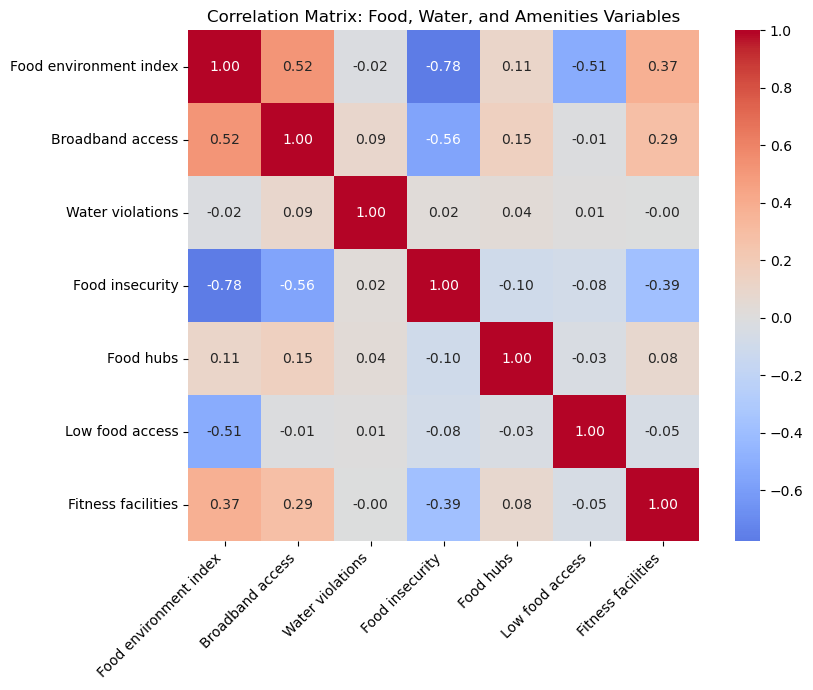

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_cols = [ #here we pick the latest data available for each category
    "food environment index raw value2025",
    "broadband access raw value2025",
    "drinking water violations raw value2025",
    "food insecurity raw value2025",
    "FOODHUB23",
    "PCT_LACCESS_POP19",
    "RECFACPTH20"
]

short_names = {
    "food environment index raw value2025": "Food environment index",
    "broadband access raw value2025": "Broadband access",
    "drinking water violations raw value2025": "Water violations",
    "food insecurity raw value2025": "Food insecurity",
    "FOODHUB23": "Food hubs",
    "PCT_LACCESS_POP19": "Low food access",
    "RECFACPTH20": "Fitness facilities"
}

corr = df_new[plot_cols].corr()
corr = corr.rename(index=short_names, columns=short_names)

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    square=True
)

ax.set_title("Correlation Matrix: Food, Water, and Amenities Variables")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

The strongest relationship is between the Food Environment Index and Food Insecurity (-0.78). This is not surprising, as the Food Environment Index was constructed using several factors, and a better index should correlate with lower food insecurity. This suggests that these two variables may contain overlapping information; however, the correlation is not high enough to drop one of the variables.

One interesting observation is the considerable correlation (0.52) between Broadband Access and a high Food Environment Index (or Food Security (0.56)).

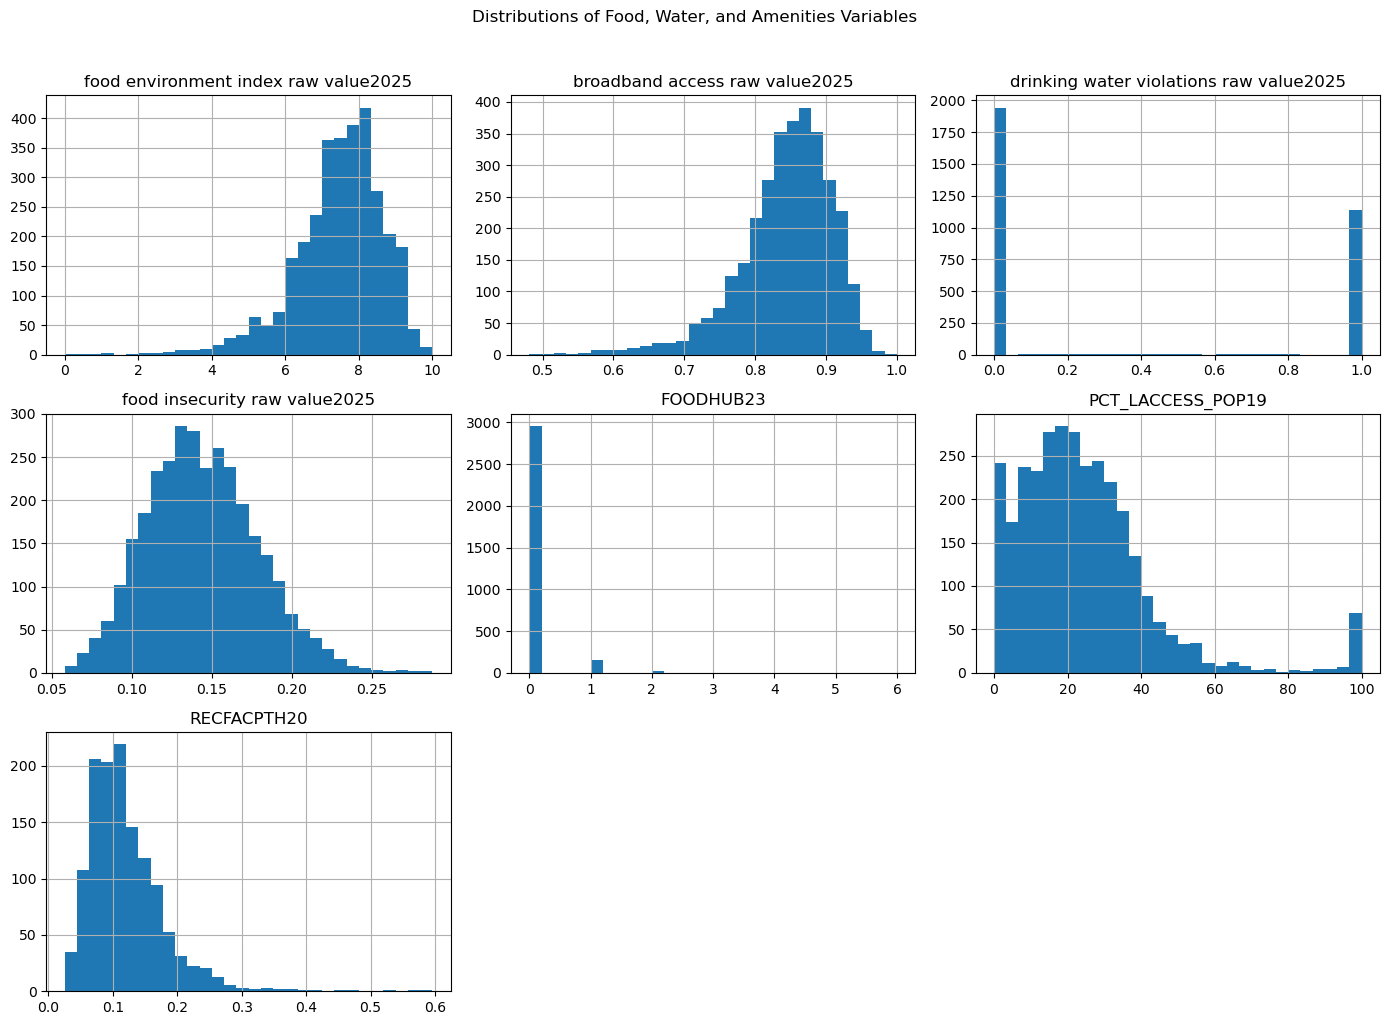

In [22]:
latest_cols = [
    "food environment index raw value2025",
    "broadband access raw value2025",
    "drinking water violations raw value2025",
    "food insecurity raw value2025",
    "FOODHUB23",
    "PCT_LACCESS_POP19",
    "RECFACPTH20"
]

df_new[latest_cols].hist(figsize=(14, 10), bins=30)

plt.suptitle("Distributions of Food, Water, and Amenities Variables", y=1.02)
plt.tight_layout()
plt.show()

## Visualization of Data
This section will visualize certain variables and their changes over the years based on the location.

In [23]:
import pandas as pd
import numpy as np
import plotly.figure_factory as ff

def bb_acc(state_name):
    broadband_cols = [
        "broadband access raw value2021",
        "broadband access raw value2022",
        "broadband access raw value2023",
        "broadband access raw value2024",
        "broadband access raw value2025"
    ]

    df_state = df[df["State"].str.lower() == state_name.lower()].copy()

    df_long = df_state.melt(
        id_vars=["FIPS", "State", "County", "Latitude", "Longitude"],
        value_vars=broadband_cols,
        var_name="variable_year",
        value_name="broadband_access"
    )

    df_long["year"] = df_long["variable_year"].str.extract(r"(\d{4})").astype(int)

    # Convert from decimal to percent
    df_long["broadband_access_percent"] = df_long["broadband_access"] * 100

    df_long = df_long.dropna(
        subset=["Latitude", "Longitude", "broadband_access_percent"]
    )

    if len(df_long) == 0:
        print(f"No usable data found for {state_name}.")
        return

    fig = ff.create_hexbin_mapbox(
        data_frame=df_long,
        lat="Latitude",
        lon="Longitude",
        color="broadband_access_percent",
        agg_func=np.mean,
        animation_frame="year",
        nx_hexagon=10,
        min_count=1,
        opacity=0.7,

        # Red = low, yellow = middle, green = high
        color_continuous_scale=[
            [0.0, "red"],
            [0.5, "yellow"],
            [1.0, "green"]
        ],

        # Fixed percent scale from 0 to 100
        range_color=[60, 100],

        labels={
            "color": "Broadband access (%)",
            "frame": "Year"
        },
        show_original_data=True
    )

    fig.update_layout(
        title=f"Broadband Access (%) in {state_name.title()}, 2021–2025",
        mapbox_style="open-street-map",
        margin=dict(b=0, t=40, l=0, r=0)
    )

    fig.show()

In [24]:
#You can use this function to see changes in Broadband Access by entering the abbreviation of the state.
bb_acc("MI")

In [25]:
import plotly.express as px

def food_env_trend(state_name):
    food_cols = [
        "food environment index raw value2014",
        "food environment index raw value2015",
        "food environment index raw value2016",
        "food environment index raw value2017",
        "food environment index raw value2018",
        "food environment index raw value2019",
        "food environment index raw value2020",
        "food environment index raw value2021",
        "food environment index raw value2022",
        "food environment index raw value2023",
        "food environment index raw value2024",
        "food environment index raw value2025"
    ]

    df_state = df[df["State"].str.lower() == state_name.lower()].copy()

    df_long = df_state.melt(
        id_vars=["FIPS", "State", "County"],
        value_vars=food_cols,
        var_name="variable_year",
        value_name="food_environment_index"
    )

    df_long["year"] = df_long["variable_year"].str.extract(r"(\d{4})").astype(int)

    state_trend = (
        df_long
        .groupby("year", as_index=False)["food_environment_index"]
        .mean()
    )

    fig = px.line(
        state_trend,
        x="year",
        y="food_environment_index",
        markers=True,
        title=f"Average Food Environment Index in {state_name.title()}, 2014–2025",
        labels={
            "year": "Year",
            "food_environment_index": "Average Food Environment Index"
        }
    )

    fig.update_yaxes(range=[0, 10])

    fig.show()

In [26]:
#You can use this function to see changes in the Food Environment Index by entering the abbreviation of the state.
#Index is calculated based on factors that contribute to a healthy food environment, from 0 (worst) to 10 (best).

food_env_trend("MI")

We would like to note that, according to the [source](https://www.countyhealthrankings.org/health-data/community-conditions/health-infrastructure/health-promotion-and-harm-reduction/food-environment-index?year=2025), the Food Environment Index considers how close a person lives to grocery stores or supermarkets, the availability of healthy food options in most communities, and whether cost or transportation barriers hinder access to healthy foods.

In [27]:
import pandas as pd
import plotly.express as px

def recfacpth_box(state_name):
    rec_cols = [
        "RECFACPTH07",
        "RECFACPTH09",
        "RECFACPTH11",
        "RECFACPTH12",
        "RECFACPTH14",
        "RECFACPTH16",
        "RECFACPTH20"
    ]

    year_map = {
        "RECFACPTH07": 2007,
        "RECFACPTH09": 2009,
        "RECFACPTH11": 2011,
        "RECFACPTH12": 2012,
        "RECFACPTH14": 2014,
        "RECFACPTH16": 2016,
        "RECFACPTH20": 2020
    }

    df_state = df[df["State"].str.lower() == state_name.lower()].copy()

    df_long = df_state.melt(
        id_vars=["FIPS", "State", "County"],
        value_vars=rec_cols,
        var_name="variable_year",
        value_name="recfacpth"
    )

    df_long["year"] = df_long["variable_year"].map(year_map)

    # Convert from facilities per 1,000 people to facilities per 10,000 people
    df_long["recfacpth_per_10000"] = df_long["recfacpth"] * 10

    df_long = df_long.dropna(subset=["year", "recfacpth_per_10000"])

    if len(df_long) == 0:
        print(f"No usable RECFACPTH data found for {state_name}.")
        return

    fig = px.box(
        df_long,
        x="year",
        y="recfacpth_per_10000",
        points="all",
        hover_name="County",
        title=f"Distribution of Recreation and Fitness Facilities per 10,000 People in {state_name.title()}",
        labels={
            "year": "Year",
            "recfacpth_per_10000": "Facilities per 10,000 people"
        }
    )

    fig.show()

In [28]:
#You can use this function to see changes in the number of Recreation and Fitness Facilities by entering the abbreviation of the state.
recfacpth_box("MI")

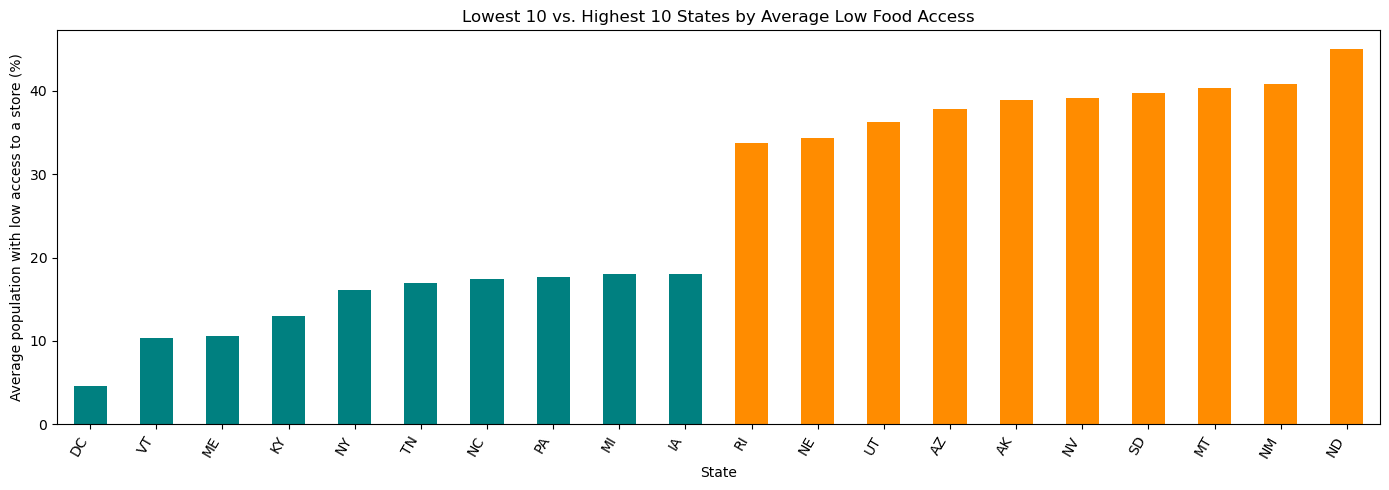

In [29]:
state_laccess = (
    df_new
    .groupby("State")["PCT_LACCESS_POP19"]
    .mean()
    .dropna()
    .sort_values()
)

state_laccess_extremes = pd.concat([
    state_laccess.head(10),
    state_laccess.tail(10)
])

fig, ax = plt.subplots(figsize=(14, 5))

state_laccess_extremes.plot(
    kind="bar",
    ax=ax,
    color=(["teal"] * 10 + ["darkorange"] * 10)
)

ax.set_title("Lowest 10 vs. Highest 10 States by Average Low Food Access")
ax.set_ylabel("Average population with low access to a store (%)")
ax.set_xlabel("State")

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Scoring using PCA

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

pca_cols = [
    "FIPS",
    "State",
    "County",
    "food environment index raw value2025",
    "broadband access raw value2025",
    "drinking water violations raw value2025",
    "food insecurity raw value2025",
    "FOODHUB23",
    "PCT_LACCESS_POP19",
    "RECFACPTH20"
]

pca_df = df_new[pca_cols].copy()

score_cols = pca_cols[3:]

# we fill missing values with median
for col in score_cols:
    pca_df[col] = pca_df[col].fillna(pca_df[col].median())

# we reverse variables where bigger is worse, so bigger is always better
pca_df["drinking water violations raw value2025"] = -pca_df["drinking water violations raw value2025"]
pca_df["food insecurity raw value2025"] = -pca_df["food insecurity raw value2025"]
pca_df["PCT_LACCESS_POP19"] = -pca_df["PCT_LACCESS_POP19"]

scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_df[score_cols])

pca = PCA(n_components=2)
pca_scores = pca.fit_transform(pca_scaled)

pca.components_, pca.explained_variance_ratio_

(array([[ 0.5857951 ,  0.47973966, -0.01102094,  0.54867611,  0.152192  ,
          0.18991865,  0.25747919],
        [ 0.2921638 , -0.25170751,  0.13834322, -0.24096311, -0.14704703,
          0.84159802, -0.21017021]]),
 array([0.34649307, 0.16893211]))

This shows that PC1 accounts for 34.6% of the variance of our variables. We will use that for creating our scoring system. We see that contributions from drinking water violations are negligible compared to those from other variables. Let's check it more carefully:

In [31]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=score_cols
)

display(loadings)

,PC1,PC2
food environment index raw value2025,0.585795,0.292164
broadband access raw value2025,0.479740,-0.251708
drinking water violations raw value2025,-0.011021,0.138343
food insecurity raw value2025,0.548676,-0.240963
FOODHUB23,0.152192,-0.147047
PCT_LACCESS_POP19,0.189919,0.841598
RECFACPTH20,0.257479,-0.210170


Notice that PC1 gives weight to the Food Environment Index, Food Security, and Broadband Access. On the other hand, PC2 heavily relies on Low Access to Store.

In [32]:
pca_df["PC1"] = pca_scores[:, 0]

pca_df["Food, Water and Amenities Score"] = (
    100 * (pca_df["PC1"] - pca_df["PC1"].min()) /
    (pca_df["PC1"].max() - pca_df["PC1"].min())
)

df_scores = pca_df.sort_values(by="Food, Water and Amenities Score", ascending=False)[["FIPS","State","County","Food, Water and Amenities Score"]]

display(df_scores)
df_scores.to_csv("Final Food, Water and Amenities Score.csv", index=False)


,FIPS,State,County,"Food, Water and Amenities Score"
1268,25019,MA,Nantucket,100.000000
308,8097,CO,Pitkin,91.323056
3214,56039,WY,Teton,91.026521
2995,51600,VA,Fairfax,90.989633
590,16013,ID,Blaine,88.607580
...,...,...,...,...
106,2290,AK,Yukon-Koyukuk,5.693208
2781,48385,TX,Real,4.614405
1505,28119,MS,Quitman,2.721535
1866,35033,NM,Mora,1.036584


# Validation

Now our goal is to check if the counties with higher custom Food, Water and Amenities Score have higher migration rates.

## Correlation between Food, Water and Amenities Scores and Migration Rates
We have the migration data by county for the last three years. We want to use average migration rates (per 1000 people). We will examine domestic, international, and total migrations.

In [33]:
scores_df = pd.read_csv("Final Food, Water and Amenities Score.csv")
migration_df = pd.read_csv("Migration Rates by County.csv")

migration_df["avg_net_domestic_migration_rate"] = migration_df[["RDOMESTICMIG2023", "RDOMESTICMIG2024", "RDOMESTICMIG2025"]].mean(axis=1)

migration_df["avg_net_international_migration_rate"] = migration_df[["RINTERNATIONALMIG2023", "RINTERNATIONALMIG2024", "RINTERNATIONALMIG2025"]].mean(axis=1)

migration_df["avg_net_total_migration_rate"] = migration_df[["RNETMIG2023", "RNETMIG2024", "RNETMIG2025"]].mean(axis=1)

validation_df = scores_df[["FIPS", "State", "County", "Food, Water and Amenities Score"]].merge(
    migration_df[["FIPS", "avg_net_domestic_migration_rate","avg_net_international_migration_rate", "avg_net_total_migration_rate"]], on="FIPS", how="left")

validation_df = validation_df.dropna(subset=["Food, Water and Amenities Score", "avg_net_international_migration_rate",  "avg_net_domestic_migration_rate","avg_net_total_migration_rate"])

display(validation_df.sample(5))

,FIPS,State,County,"Food, Water and Amenities Score",avg_net_domestic_migration_rate,avg_net_international_migration_rate,avg_net_total_migration_rate
1334,20101,KS,Lane,55.840413,-3.691076,0.000000,-3.691076
1605,39047,OH,Fayette,53.731695,0.414329,0.220599,0.634928
3098,32009,NV,Esmeralda,28.786501,2.723416,-3.628138,-0.904722
154,19119,IA,Lyon,72.168965,1.308223,1.737442,3.045665
2461,13045,GA,Carroll,44.965785,13.012436,3.333407,16.345843


In [34]:
pearson_corr = validation_df["Food, Water and Amenities Score"].corr(
    validation_df["avg_net_domestic_migration_rate"],
    method="pearson"
)

spearman_corr = validation_df["Food, Water and Amenities Score"].corr(
    validation_df["avg_net_domestic_migration_rate"],
    method="spearman"
)

print("Using Average Net Domestic Migration Rate, we got:")
print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

pearson_corr = validation_df["Food, Water and Amenities Score"].corr(
    validation_df["avg_net_international_migration_rate"],
    method="pearson"
)

spearman_corr = validation_df["Food, Water and Amenities Score"].corr(
    validation_df["avg_net_international_migration_rate"],
    method="spearman"
)

print("Using Average Net International Migration Rate, we got:")
print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

pearson_corr = validation_df["Food, Water and Amenities Score"].corr(
    validation_df["avg_net_total_migration_rate"],
    method="pearson"
)

spearman_corr = validation_df["Food, Water and Amenities Score"].corr(
    validation_df["avg_net_total_migration_rate"],
    method="spearman"
)

print("Using Average Net International Migration Rate, we got:")
print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)


Using Average Net Domestic Migration Rate, we got:
Pearson correlation: 0.05095392190479387
Spearman correlation: -0.024689955899197525
Using Average Net International Migration Rate, we got:
Pearson correlation: 0.21327988815261795
Spearman correlation: 0.29127524350720907
Using Average Net International Migration Rate, we got:
Pearson correlation: 0.1284530847067406
Spearman correlation: 0.05980327188795797


The Food, Water, and Amenities score is not strongly related to domestic migration, but it shows a slight positive relation to international migration. This shows that this category alone does not explain overall migration patterns, which is expected, since many other factors such as jobs, schools, housing, and affordability probably affect migration rates more strongly than food-related concerns. However, we did capture some connection with international migration, which is an interesting point.

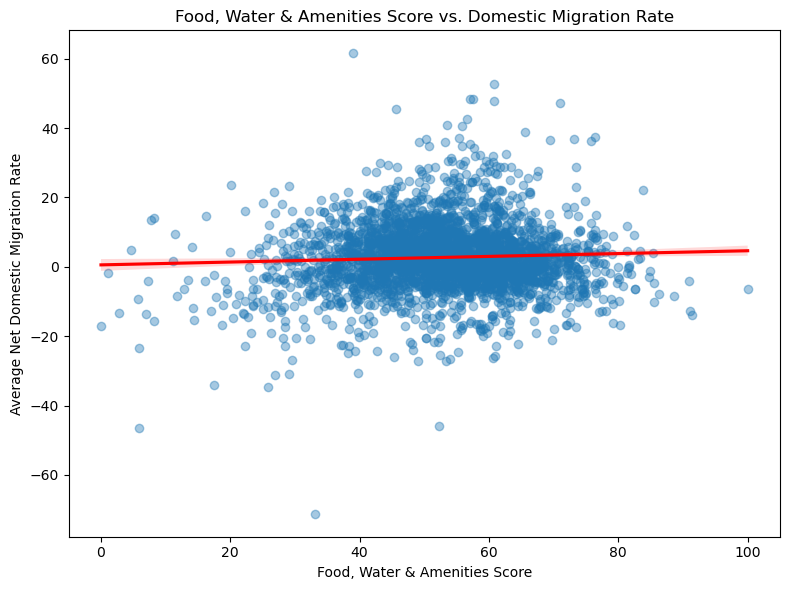

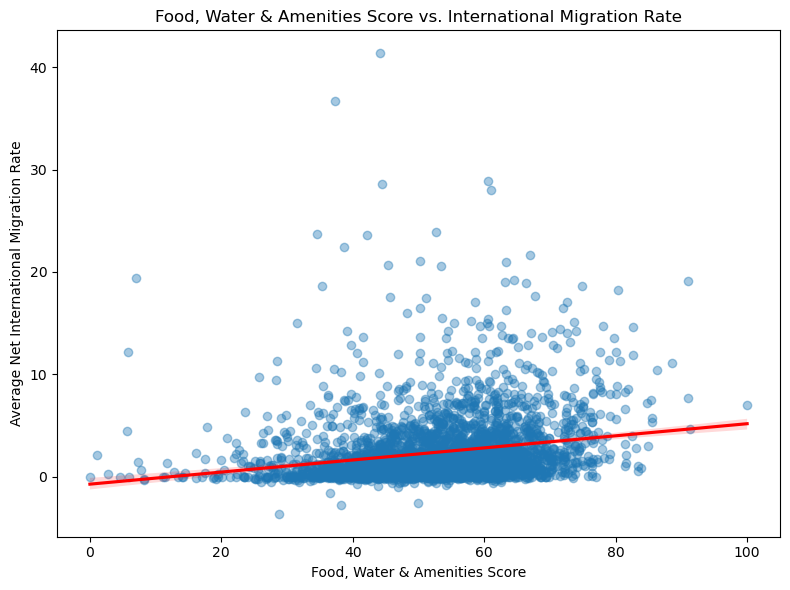

In [35]:

# for domestic migration
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=validation_df,
    x="Food, Water and Amenities Score",
    y="avg_net_domestic_migration_rate",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"},
    ax=ax
)

ax.set_title("Food, Water & Amenities Score vs. Domestic Migration Rate")
ax.set_xlabel("Food, Water & Amenities Score")
ax.set_ylabel("Average Net Domestic Migration Rate")

plt.tight_layout()
plt.show()


# for international migration
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=validation_df,
    x="Food, Water and Amenities Score",
    y="avg_net_international_migration_rate",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"},
    ax=ax
)

ax.set_title("Food, Water & Amenities Score vs. International Migration Rate")
ax.set_xlabel("Food, Water & Amenities Score")
ax.set_ylabel("Average Net International Migration Rate")

plt.tight_layout()
plt.show()